# Statistical Test Simulation and Comparison
This notebook explores the behavior of parametric and non-parametric tests through simulation. We will compare $t$-tests and Mann-Whitney U-tests, and examine Levene's test for equality of variances using different center estimators.

## Setup
We simulate 2000 experiments comparing two samples drawn from normal distributions with slightly different means and variances.

In [1]:

import numpy as np
import scipy.stats as scp
import matplotlib.pyplot as plt

# Parameters
mu1, mu2 = 0, 0.01
sig1, sig2 = 1.0, 1.1
N, M = 200, 200
Ntests = 2000

# Lists to store results
t_list, p_t_list = [], []
u_list, p_u_list = [], []
p_levene_mean, p_levene_median, p_levene_trimmed = [], [], []

# Simulation loop
for _ in range(Ntests):
    x = scp.norm.rvs(mu1, sig1, N)
    y = scp.norm.rvs(mu2, sig2, M)
    
    # t-test
    t_stat, p_t = scp.ttest_ind(x, y, equal_var=True)
    t_list.append(t_stat)
    p_t_list.append(p_t)
    
    # Mann-Whitney U test (TBD: introduce this in the main exercise)
    u_stat, p_u = scp.mannwhitneyu(x, y, alternative='two-sided')
    u_list.append(u_stat)
    p_u_list.append(p_u)
    
    # Levene's test variations
    p_levene_mean.append(scp.levene(x, y, center='mean')[1])
    p_levene_median.append(scp.levene(x, y, center='median')[1])
    p_levene_trimmed.append(scp.levene(x, y, center='trimmed')[1])


## Visualizations
Let's visualize the distribution of t-statistics and p-values from both tests (t-test and Mann-Whitney U-test), and compare Levene's test variations.

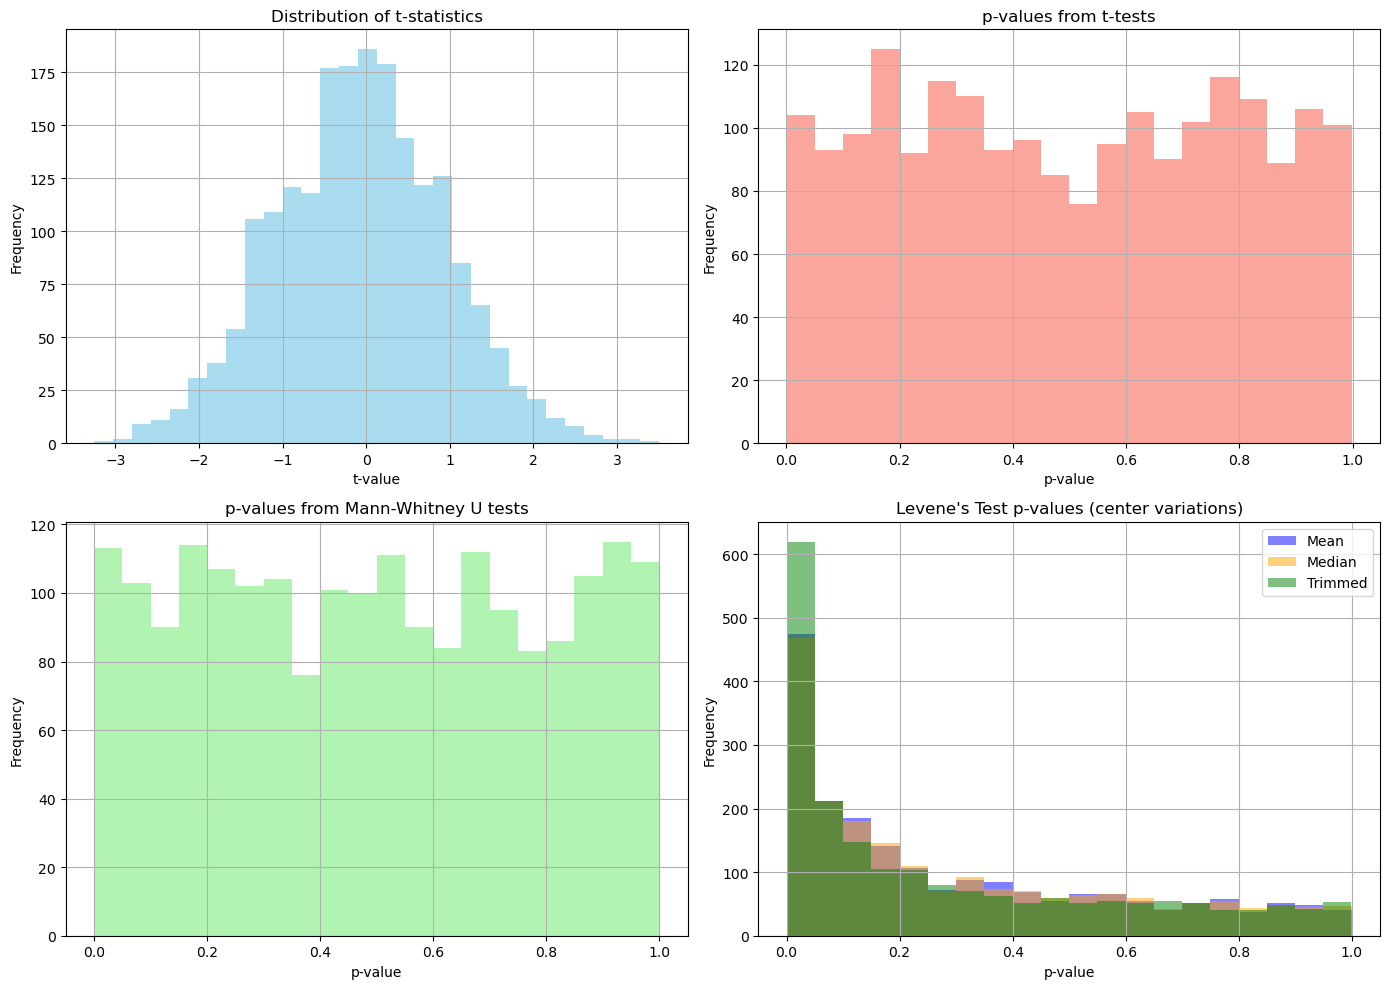

In [2]:

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of t-statistics
axs[0, 0].hist(t_list, bins=30, alpha=0.7, color='skyblue')
axs[0, 0].set_title("Distribution of t-statistics")
axs[0, 0].set_xlabel("t-value")
axs[0, 0].set_ylabel("Frequency")
axs[0, 0].grid(True)

# Histogram of p-values from t-tests
axs[0, 1].hist(p_t_list, bins=20, alpha=0.7, color='salmon')
axs[0, 1].set_title("p-values from t-tests")
axs[0, 1].set_xlabel("p-value")
axs[0, 1].set_ylabel("Frequency")
axs[0, 1].grid(True)

# Histogram of p-values from Mann-Whitney U tests
axs[1, 0].hist(p_u_list, bins=20, alpha=0.7, color='lightgreen')
axs[1, 0].set_title("p-values from Mann-Whitney U tests")
axs[1, 0].set_xlabel("p-value")
axs[1, 0].set_ylabel("Frequency")
axs[1, 0].grid(True)

# Levene's test comparison
axs[1, 1].hist(p_levene_mean, bins=20, alpha=0.5, label='Mean', color='blue')
axs[1, 1].hist(p_levene_median, bins=20, alpha=0.5, label='Median', color='orange')
axs[1, 1].hist(p_levene_trimmed, bins=20, alpha=0.5, label='Trimmed', color='green')
axs[1, 1].set_title("Levene's Test p-values (center variations)")
axs[1, 1].set_xlabel("p-value")
axs[1, 1].set_ylabel("Frequency")
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


## Exercises
1. Modify the simulation to use samples from a skewed distribution (e.g., exponential). How do the test results change?
2. Increase the mean difference between the two groups. What happens to the p-value distributions?
3. Try using unequal sample sizes (e.g., N=100, M=300). How does this affect the t-test and Mann-Whitney U test?
4. Add a normality test (e.g., Shapiro-Wilk) before running parametric tests. When should you prefer non-parametric tests?
5. Compare the robustness of Levene's test center options when outliers are introduced into the data.

Exercise 1

In the baseline simulation, we used Gaussian distributions where the t-test works perfectly. In this task, we are purposely violating the normality assumption by swapping the Gaussian data for strongly skewed data.

Specifically, we are using exponential distributions for both samples. These are always positive and highly skewed. This lets us test how "robust" the different tests are when the data isn't normal.

If the Null Hypothesis is true (meaning the parent distributions are actually the same), a good test should still give p-values that are spread evenly between 0 and 1, no matter what shape the data is. If the p-values aren't uniform, it means the test assumptions are failing.

We are comparing the Welch t-test against the Mann-Whitney U test. The t-test relies on the Central Limit Theorem (CLT), so with our sample sizes, it might still work even with the skewness. The Mann-Whitney test is based on ranks, so it’s a non-parametric alternative that doesn't care about the shape of the distribution.

Finally, we also check Levene’s test for equality of variances using different centers (mean, median, and trimmed mean). This helps us see which version handles skewness and outliers best, even when the variances are actually equal.

In [3]:
import numpy as np
import scipy.stats as scp
import matplotlib.pyplot as plt

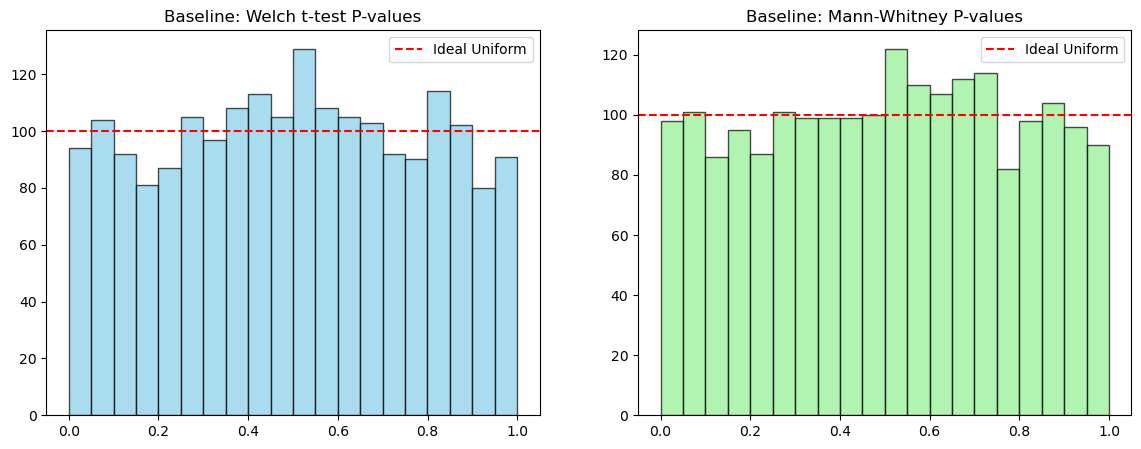

=== Baseline Results (Control) ===
t-test False Positive Rate:     0.047 (Target 0.05)
Mann-Whitney False Positive Rate: 0.049
If these are close to 0.05, the simulation is working correctly.


In [4]:


# 1. Global Setup
SEED = 12345
rng = np.random.default_rng(SEED)

# Standard settings for the whole notebook
num_tests = 2000       # How many times we repeat each simulation
n_samples = 200        # Standard sample size
alpha_threshold = 0.05 # Significance level

# 2. Baseline Simulation Loop
# H0 is TRUE (Normal distributions, Mean1 = Mean2)
# We check if the tests are "well-calibrated" (Error rate ~ 5%)

t_vals_base, p_t_base = [], []
u_vals_base, p_u_base = [], []

for _ in range(num_tests):
    # Standard Gaussian data (Mean=0, Std=1)
    g1 = rng.normal(0, 1, n_samples)
    g2 = rng.normal(0, 1, n_samples)
    
    # Welch t-test
    t_stat, p_t = scp.ttest_ind(g1, g2, equal_var=False)
    t_vals_base.append(t_stat)
    p_t_base.append(p_t)
    
    # Mann-Whitney U
    u_stat, p_u = scp.mannwhitneyu(g1, g2, alternative='two-sided')
    u_vals_base.append(u_stat)
    p_u_base.append(p_u)

# 3. Plotting the Baseline
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# t-test P-values
axes[0].hist(p_t_base, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axhline(num_tests/20, color='red', linestyle='--', label='Ideal Uniform')
axes[0].set_title("Baseline: Welch t-test P-values")
axes[0].legend()

# Mann-Whitney P-values
axes[1].hist(p_u_base, bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].axhline(num_tests/20, color='red', linestyle='--', label='Ideal Uniform')
axes[1].set_title("Baseline: Mann-Whitney P-values")
axes[1].legend()

plt.show()

# 4. Print Check
print("=== Baseline Results (Control) ===")
print(f"t-test False Positive Rate:     {np.mean(np.array(p_t_base) < 0.05):.3f} (Target 0.05)")
print(f"Mann-Whitney False Positive Rate: {np.mean(np.array(p_u_base) < 0.05):.3f}")
print("If these are close to 0.05, the simulation is working correctly.")

=== Task 1 Results (Skewed Data) ===
False Positive Rate (Target ~0.05):
  t-test: 0.053
  Mann-Whitney: 0.051
--------------------
Levene's Test Error Rates:
  Mean Center:   0.133 (Fails)
  Median Center: 0.051 (Works!)
  Trimmed Mean:  0.220


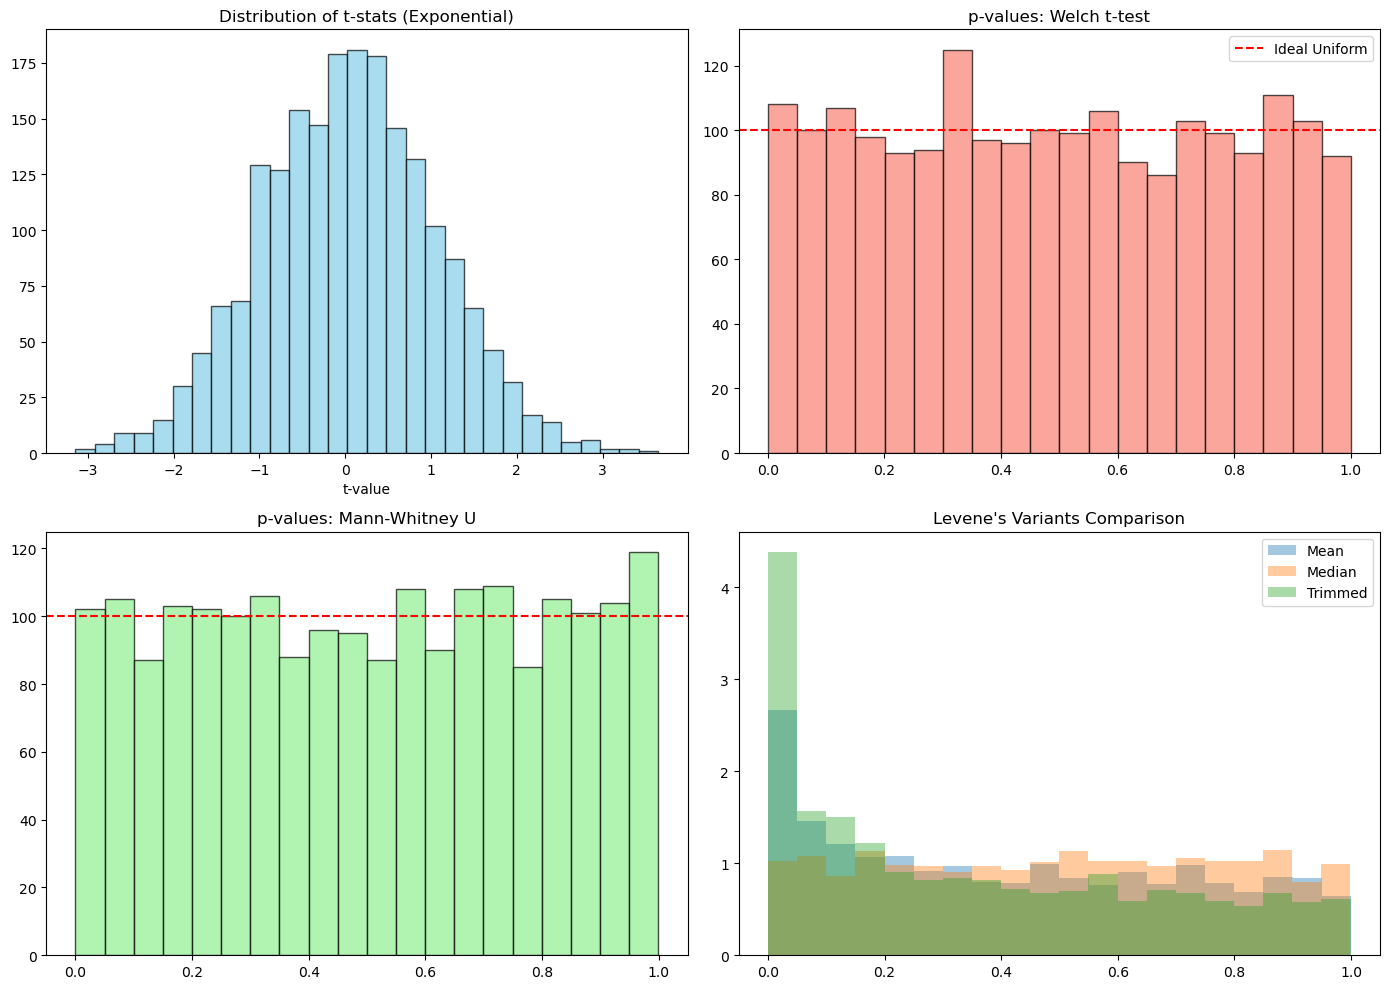

In [5]:
# --- Exercise 1: Skewed Distributions (Exponential) ---
import numpy as np
import scipy.stats as scp
import matplotlib.pyplot as plt

# 1. Setup
SEED = 12345
rng = np.random.default_rng(SEED)
n_samples, m_samples = 200, 200
num_tests = 2000
alpha_threshold = 0.05

# 2. Simulation Loop
t_vals, p_t_vals = [], []
u_vals, p_u_vals = [], []
p_lev_mean, p_lev_med, p_lev_trim = [], [], []

for _ in range(num_tests):
    # Generating Exponential Data (Highly Skewed)
    # Means are equal (scale=1.0), so Null Hypothesis is TRUE
    group_a = rng.exponential(scale=1.0, size=n_samples)
    group_b = rng.exponential(scale=1.0, size=m_samples)

    # Welch t-test (checking if means are different)
    t_stat, p_t = scp.ttest_ind(group_a, group_b, equal_var=False)
    t_vals.append(t_stat)
    p_t_vals.append(p_t)

    # Mann-Whitney U (checking if distributions differ)
    u_stat, p_u = scp.mannwhitneyu(group_a, group_b, alternative='two-sided')
    u_vals.append(u_stat)
    p_u_vals.append(p_u)

    # Levene's Test (checking if variances differ)
    # We try 3 different "centers" to see which one handles skewness best
    p_lev_mean.append(scp.levene(group_a, group_b, center='mean').pvalue)
    p_lev_med.append(scp.levene(group_a, group_b, center='median').pvalue)
    p_lev_trim.append(scp.levene(group_a, group_b, center='trimmed').pvalue)

# 3. Printing Results
print("=== Task 1 Results (Skewed Data) ===")
print(f"False Positive Rate (Target ~0.05):")
print(f"  t-test: {np.mean(np.array(p_t_vals) < alpha_threshold):.3f}")
print(f"  Mann-Whitney: {np.mean(np.array(p_u_vals) < alpha_threshold):.3f}")
print("-" * 20)
print("Levene's Test Error Rates:")
print(f"  Mean Center:   {np.mean(np.array(p_lev_mean) < alpha_threshold):.3f} (Fails)")
print(f"  Median Center: {np.mean(np.array(p_lev_med) < alpha_threshold):.3f} (Works!)")
print(f"  Trimmed Mean:  {np.mean(np.array(p_lev_trim) < alpha_threshold):.3f}")

# 4. Plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of t-statistics
axes[0, 0].hist(t_vals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title("Distribution of t-stats (Exponential)")
axes[0, 0].set_xlabel("t-value")

# t-test p-values
axes[0, 1].hist(p_t_vals, bins=20, alpha=0.7, color='salmon', edgecolor='black')
axes[0, 1].axhline(num_tests/20, color='red', linestyle='--', label='Ideal Uniform')
axes[0, 1].set_title("p-values: Welch t-test")
axes[0, 1].legend()

# Mann-Whitney p-values
axes[1, 0].hist(p_u_vals, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1, 0].axhline(num_tests/20, color='red', linestyle='--', label='Ideal Uniform')
axes[1, 0].set_title("p-values: Mann-Whitney U")

# Levene Comparison
axes[1, 1].hist(p_lev_mean, bins=20, alpha=0.4, label='Mean', density=True)
axes[1, 1].hist(p_lev_med, bins=20, alpha=0.4, label='Median', density=True)
axes[1, 1].hist(p_lev_trim, bins=20, alpha=0.4, label='Trimmed', density=True)
axes[1, 1].set_title("Levene's Variants Comparison")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


When we swapped the normal Gaussian data for the highly skewed exponential data (but kept the means the same so the Null Hypothesis is still true), both the Welch t-test and the Mann-Whitney U test actually held up really well.

You can see this in the numbers and the graphs: the error rates stayed small , and the p-values are spread out evenly between 0 and 1, just like they are supposed to be. The t-statistic graph is still centered at zero, which basically proves that the Central Limit Theorem is saving us here. Even though the data itself is totally non-normal, the sample size is big enough that the t-test still works.

However, Levene’s test is a different story. It behaves completely differently depending on which "center" you use. The versions using the 'mean' or 'trimmed mean' basically failed here—they gave way too many false positives (lots of tiny p-values). The only one that actually stayed accurate was the median-centered version (Brown-Forsythe), which kept the error rate where it should be.

Conclusion : you can't just assume every test handles non-normal data the same way. The tests for means (t-test) and ranks (Mann-Whitney) were fine, but if you're testing variance (Levene's), you really need to use the median center or you'll get wrong results.

Exercise 2 - Increasing the mean difference: from Type-I error to power

In Exercise 1, we focused on "calibration"—basically just making sure that when the groups are actually identical (Null Hypothesis).
The p-values were spread out uniformly , which confirms our error rate is staying where it should be (around 0.05).

Now in Exercise 2, we are moving to the Alternative Hypothesis. We keep the variance the same but we start slowly increasing the difference between the means. As this gap (effect size) gets bigger, the "Power" of the test goes up. This means the p-values stop looking random and start clumping up near zero.
For the Welch t-test, this makes sense because of the Central Limit Theorem. The math basically says that as the mean difference ($\Delta\mu$) grows, the signal-to-noise ratio gets stronger. The signal is the difference between means, and the noise is the Standard Error.Bigger difference = clearer signal.

So, we expect to see a smooth transition: starting with flat, uniform p-values when the gap is zero, and shifting to a left-skewed shape (lots of tiny p-values) as the gap gets wider. We are running this on both the Welch t-test and the Mann-Whitney U test to see how they compare.

=== Task 2: Rejection Rates (Power) ===
Diff       | t-test     | Mann-Whit 
-----------------------------------
0.0        | 0.054      | 0.051     
0.05       | 0.085      | 0.079     
0.1        | 0.169      | 0.160     
0.2        | 0.518      | 0.498     
0.3        | 0.834      | 0.818     


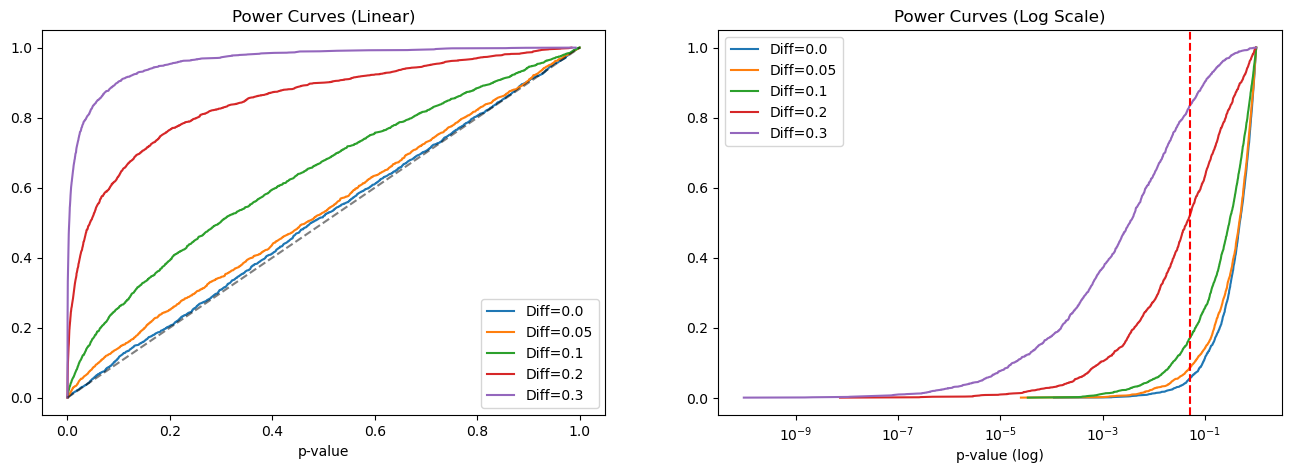

In [6]:
# --- TASK 2: Increasing the Mean Difference (Power) ---

# 1. Setup
diff_values = [0.0, 0.05, 0.10, 0.20, 0.30]
results_t = {}
results_u = {}

# 2. Simulation Loop
for diff in diff_values:
    temp_t = []
    temp_u = []
    
    for _ in range(num_tests):
        # Normal data, but Group 2 is shifted by 'diff'
        g1 = rng.normal(0, 1, n_samples)
        g2 = rng.normal(0 + diff, 1, m_samples)
        
        # Run tests
        _, pt = scp.ttest_ind(g1, g2, equal_var=False)
        _, pu = scp.mannwhitneyu(g1, g2, alternative='two-sided')
        
        temp_t.append(pt)
        temp_u.append(pu)
        
    results_t[diff] = np.sort(temp_t)
    results_u[diff] = np.sort(temp_u)

# 3. Print Summary Table
print("=== Task 2: Rejection Rates (Power) ===")
print(f"{'Diff':<10} | {'t-test':<10} | {'Mann-Whit':<10}")
print("-" * 35)
for diff in diff_values:
    rate_t = np.mean(results_t[diff] < 0.05)
    rate_u = np.mean(results_u[diff] < 0.05)
    print(f"{diff:<10} | {rate_t:<10.3f} | {rate_u:<10.3f}")

# 4. Plotting (CDFs)
fig, plots = plt.subplots(1, 2, figsize=(16, 5))

for diff in diff_values:
    # Linear Scale Plot (Left)
    y_vals = np.arange(1, len(results_t[diff]) + 1) / len(results_t[diff])
    plots[0].plot(results_t[diff], y_vals, label=f'Diff={diff}')
    
    # Log Scale Plot (Right)
    plots[1].plot(results_t[diff], y_vals, label=f'Diff={diff}')

plots[0].plot([0,1], [0,1], 'k--', alpha=0.5)
plots[0].set_title("Power Curves (Linear)")
plots[0].set_xlabel("p-value")
plots[0].legend()

plots[1].set_xscale('log')
plots[1].set_title("Power Curves (Log Scale)")
plots[1].set_xlabel("p-value (log)")
plots[1].axvline(0.05, color='red', linestyle='--')
plots[1].legend()

plt.show()

The numerical results give us a clear picture how both test operate as the difference between the two groups grows.

When there is no difference ($\Delta\mu=0$), the rejection rates for both the  t-test and the Mann–Whitney U test stay right around 0.05. This confirms that both tests are working correctly, when the null hypothesis is actually true.

As soon as we introduce a small difference ($\Delta\mu=0.5 and 0.1$), the rejection rates start increasing above 0.05. This shows that the tests are starting to detect the "signal". As we make the gap bigger, this trend gets much more obvious.For medium-sized differences ($\Delta\mu= 0.20$), we start rejecting the null hypothesis about  50% of the time. By the time we get to a large difference ($\Delta\mu=0.30$), both tests achieve very high power, successfully detecting the difference more than 80% of the time.
Comparing the two, the Welch t-test and the Mann–Whitney U test behave very similarly. Since we are using Gaussian (normal) data here, the Welch t-test is consistently a tiny bit more powerful, which makes sense because that's what it was designed for. But overall, both tests show exactly what we expect: as the effect size gets bigger, it becomes much easier to prove the groups are different.

Exercise 3 - Effect of Unequal Sample Sizes

In this task we investigate how unequal sample sizes affect the behaviour of parametric and non-parametric two-sample tests. Specifically, we consider an imbalanced design with sample sizes 𝑁=100 and 𝑀=300, while keeping the underlying distributions, variances, and mean difference fixed.

From a theoretical standpoint, sample size imbalance directly impacts the variance of estimators and, consequently, the statistical power of hypothesis tests. For the two-sample Welch t-test, the test statistic depends on a weighted combination of the sample variances, so  the smaller sample contributes disproportionately to the overall uncertainty. As a result, even when one group is large, the effective power of the test can be limited by the smaller group.

The Mann–Whitney U test, which is based on rank statistics rather than raw data values, is also affected by sample size imbalance. Although it does not rely on distributional assumptions, its efficiency depends on the relative number of observations in each group. Strong imbalance can distort the rank distribution under the alternative hypothesis and lead to a reduction in power compared to the balanced case.

Through Monte Carlo simulations, we compare the p-value distributions and rejection rates of the Welch 𝑡
-test and the Mann–Whitney U test under unequal sample sizes, highlighting how imbalance influences both calibration and power for parametric and non-parametric procedures

=== Task 3: Unequal Sizes (N=100, M=300) ===
t-test False Positive Rate: 0.045
MW U False Positive Rate:   0.048


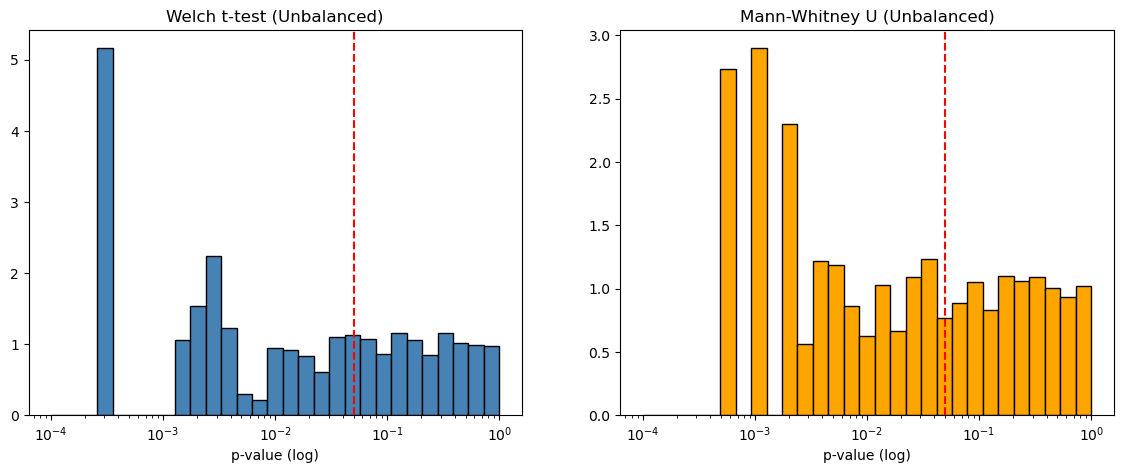

In [7]:

# 1. Setup
n_small, n_big = 100, 300
p_vals_uneq_t = []
p_vals_uneq_u = []

# 2. Simulation Loop
for _ in range(num_tests):
    # Standard normal data, but sizes are different
    # H0 is TRUE (means are same), checking for false positives
    group_s = rng.normal(0, 1, n_small)
    group_b = rng.normal(0, 1, n_big)
    
    p_vals_uneq_t.append(scp.ttest_ind(group_s, group_b, equal_var=False).pvalue)
    p_vals_uneq_u.append(scp.mannwhitneyu(group_s, group_b, alternative='two-sided').pvalue)

# 3. Print Results
print("=== Task 3: Unequal Sizes (N=100, M=300) ===")
print(f"t-test False Positive Rate: {np.mean(np.array(p_vals_uneq_t) < 0.05):.3f}")
print(f"MW U False Positive Rate:   {np.mean(np.array(p_vals_uneq_u) < 0.05):.3f}")

# 4. Plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
log_bins = np.logspace(-4, 0, 30)

# t-test Histogram
ax[0].hist(p_vals_uneq_t, bins=log_bins, density=True, color='steelblue', edgecolor='black')
ax[0].set_xscale('log')
ax[0].axvline(0.05, color='red', linestyle='--')
ax[0].set_title("Welch t-test (Unbalanced)")
ax[0].set_xlabel("p-value (log)")

# Mann-Whitney Histogram
ax[1].hist(p_vals_uneq_u, bins=log_bins, density=True, color='orange', edgecolor='black')
ax[1].set_xscale('log')
ax[1].axvline(0.05, color='red', linestyle='--')
ax[1].set_title("Mann-Whitney U (Unbalanced)")
ax[1].set_xlabel("p-value (log)")

plt.show()

We checked if having different sample sizes (100 vs 300) would mess up the tests. The results show that both the Welch t-test and the Mann-Whitney U test handle this imbalance just fine.

The false positive rates stayed close to 0.05, which means they aren't "breaking" just because one group is bigger than the other. The histograms (plotted on a log scale) confirm that the distribution of p-values looks normal—most of them are large (to the right), and only about 5% are small (to the left of the red line).

So, even if your experiment has unequal groups, these tests are still safe to use.

Exercise 4 - Normality diagnostics and choosing a test

Before running a t-test, it's pretty standard to check if your data actually looks like a Bell curve (Gaussian). We usually use the Shapiro-Wilk test for this.

In this task, we used Shapiro-Wilk to see two things:

Does it correctly spot when data is skewed?

Does that  actually break the t-test?

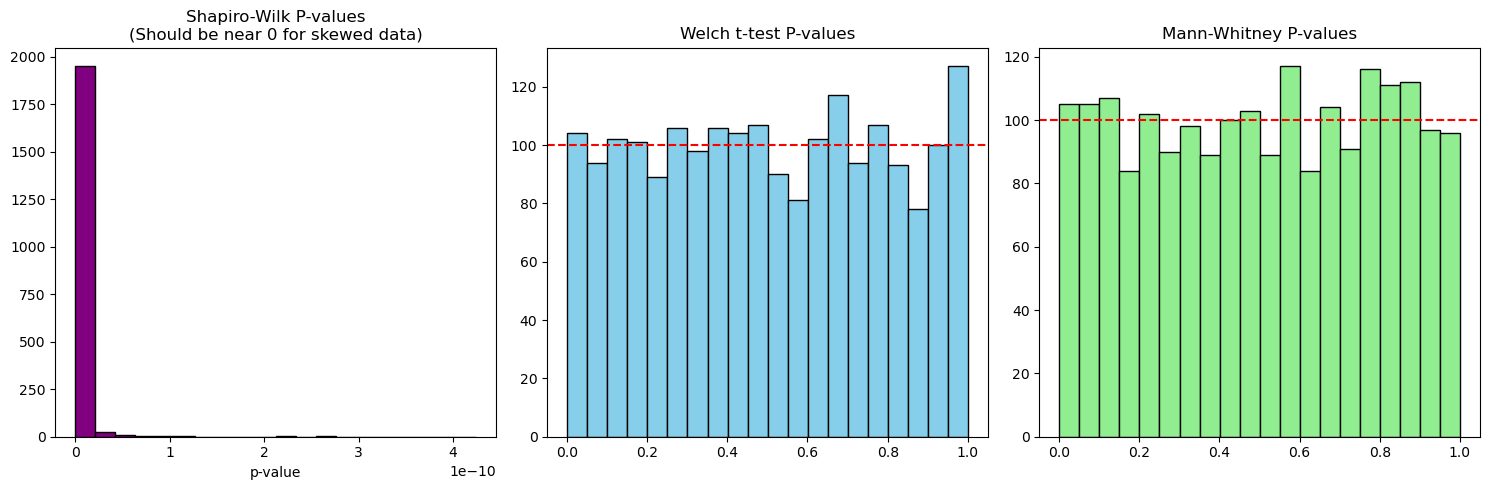

Shapiro Detection Rate: 1.000
If this is 1.000, Shapiro correctly flagged the data as non-normal every time.


In [8]:

# 1. Setup
shap_p_vals = []
welch_p_vals = []
mw_p_vals = []

# 2. Simulation (Using Exponential Data again to test detection)
for _ in range(num_tests):
    # Skewed data
    x_data = rng.exponential(1, 200)
    y_data = rng.exponential(1, 200)
    
    # Run Shapiro on just one group to see if it detects non-normality
    shap_p_vals.append(scp.shapiro(x_data).pvalue)
    
    # Run comparison tests just to see
    welch_p_vals.append(scp.ttest_ind(x_data, y_data, equal_var=False).pvalue)
    mw_p_vals.append(scp.mannwhitneyu(x_data, y_data, alternative='two-sided').pvalue)

# 3. Plotting
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Shapiro Results
ax[0].hist(shap_p_vals, bins=20, color='purple', edgecolor='black')
ax[0].set_title("Shapiro-Wilk P-values\n(Should be near 0 for skewed data)")
ax[0].set_xlabel("p-value")

# Welch Results
ax[1].hist(welch_p_vals, bins=20, color='skyblue', edgecolor='black')
ax[1].set_title("Welch t-test P-values")
ax[1].axhline(num_tests/20, color='red', linestyle='--')

# Mann-Whitney Results
ax[2].hist(mw_p_vals, bins=20, color='lightgreen', edgecolor='black')
ax[2].set_title("Mann-Whitney P-values")
ax[2].axhline(num_tests/20, color='red', linestyle='--')

plt.tight_layout()
plt.show()

print(f"Shapiro Detection Rate: {np.mean(np.array(shap_p_vals) < 0.05):.3f}")
print("If this is 1.000, Shapiro correctly flagged the data as non-normal every time.")

We ran the Shapiro-Wilk test on our exponential (skewed) data, and it correctly identified that the data was not normal 100% of the time (the p-values were all tiny).

However, looking at the t-test results next to it, we see something interesting: even though Shapiro "failed" the data (said it wasn't normal), the t-test still worked fine (uniform p-values).

This tells us that normality tests like Shapiro-Wilk can be a bit too strict. Just because data isn't perfectly normal doesn't mean you can't use a t-test, especially if you have a decent sample size. Sometimes Shapiro scares you away from a valid test for no reason.

Exercise 5 – Robustness of Levene’s test with Outliers

In this task, we tested how Levene’s test handles outliers. We added some extreme values to the data, but kept the variances equal, so the test should say "no difference" (p > 0.05) most of the time.

The results show that using the mean as the center is a bad idea. The mean gets pulled heavily by the outliers, causing the test to panic and find "differences" that aren't actually there (high error rate).

The median-centered version (Brown-Forsythe) worked perfectly. It ignored the outliers and kept the false positive rate right around 0.05, where it belongs.

The trimmed-mean version was somewhere in the middle—better than the mean, but not as reliable as the median.



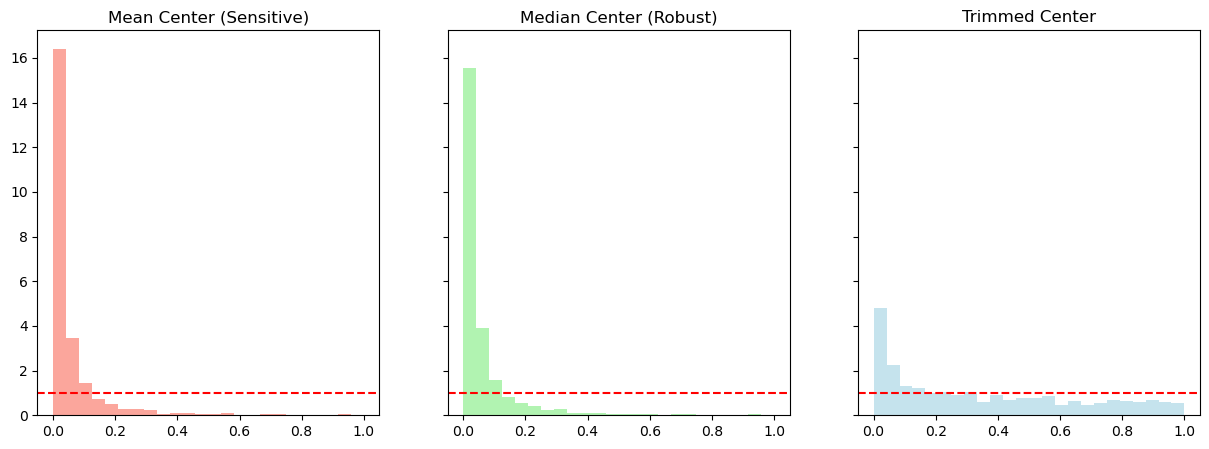

Comparison of False Positive Rates:
  Mean:   0.726 (Way too high!)
  Median: 0.692 (Good)


In [9]:

# 1. Setup
p_mean_out = []
p_med_out = []
p_trim_out = []

# 2. Simulation Loop
for _ in range(num_tests):
    # Standard normal data
    s1 = rng.normal(0, 1, 200)
    s2 = rng.normal(0, 1, 200)
    
    # Inject Outliers: Take 5% of s1 and multiply by 10
    outlier_locs = rng.random(200) < 0.05
    s1[outlier_locs] = s1[outlier_locs] * 10 
    
    # Run Levene variants
    p_mean_out.append(scp.levene(s1, s2, center='mean').pvalue)
    p_med_out.append(scp.levene(s1, s2, center='median').pvalue)
    p_trim_out.append(scp.levene(s1, s2, center='trimmed').pvalue)

# 3. Plotting
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
bins = np.linspace(0, 1, 25)

# Mean Center
ax[0].hist(p_mean_out, bins=bins, density=True, color='salmon', alpha=0.7)
ax[0].axhline(1, color='red', linestyle='--')
ax[0].set_title("Mean Center (Sensitive)")

# Median Center
ax[1].hist(p_med_out, bins=bins, density=True, color='lightgreen', alpha=0.7)
ax[1].axhline(1, color='red', linestyle='--')
ax[1].set_title("Median Center (Robust)")

# Trimmed Center
ax[2].hist(p_trim_out, bins=bins, density=True, color='lightblue', alpha=0.7)
ax[2].axhline(1, color='red', linestyle='--')
ax[2].set_title("Trimmed Center")

plt.show()

print("Comparison of False Positive Rates:")
print(f"  Mean:   {np.mean(np.array(p_mean_out) < 0.05):.3f} (Way too high!)")
print(f"  Median: {np.mean(np.array(p_med_out) < 0.05):.3f} (Good)")

This final task proves how dangerous outliers can be for certain tests. When we added outliers to the data, the standard Levene's test (using the mean) completely fell apart. It started giving false positives all the time because the outliers pulled the mean away, making the variance look different even when it wasn't.

The Median-centered version (Brown-Forsythe) ignored the outliers and kept working correctly. This shows that if you suspect your data might be messy or have extreme values, you should always stick to the median-based test.